In [1]:
from fastai.vision.all import *

from self_supervised.augmentations import *
from self_supervised.layers import *
from self_supervised.vision.simclr import *

In [2]:
help(get_image_files)

Help on function get_image_files in module fastai.data.transforms:

get_image_files(path, recurse=True, folders=None)
    Get image files in `path` recursively, only in `folders`, if specified.



In [3]:
def get_dls(path, size=256, batch_size=64):
    files = get_image_files(path)
    tfms = [[PILImage.create, ToTensor, RandomResizedCrop(size, min_scale=1.)], 
            [parent_label, Categorize()]]
    dsets = Datasets(files, tfms=tfms, splits=RandomSplitter(valid_pct=0.1)(files))
    batch_tfms = [IntToFloatTensor]
    dls = dsets.dataloaders(bs=batch_size, num_workers=4, after_batch=batch_tfms)
    return dls

In [4]:
dls = get_dls("../../data/RSSCN7/data")

In [5]:
encoder = create_encoder("tf_mobilenetv3_large_100.in1k", pretrained=False)

In [6]:
model = create_simclr_model(encoder)

In [7]:
aug_pipelines = get_simclr_aug_pipelines(size=224, rotate=True, rotate_deg=10, jitter=True, bw=True, blur=False)

In [8]:
cbs=[SimCLR(aug_pipelines)]

In [9]:
learn = Learner(dls, model, cbs=cbs).to_fp16()


/home/dnth/Desktop/self-supervised-timm/.venv/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/home/dnth/Desktop/self-supervised-timm/.venv/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


/home/dnth/Desktop/self-supervised-timm/.venv/lib/python3.11/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_l

SuggestedLRs(valley=0.002511886414140463)

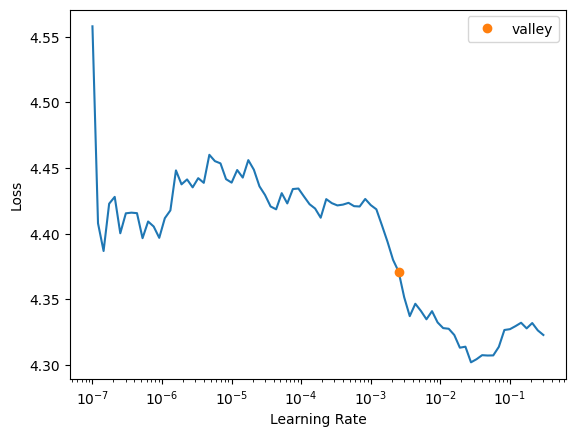

In [10]:
learn.lr_find()

epoch,train_loss,valid_loss,time
0,4.244003,3.792416,00:09


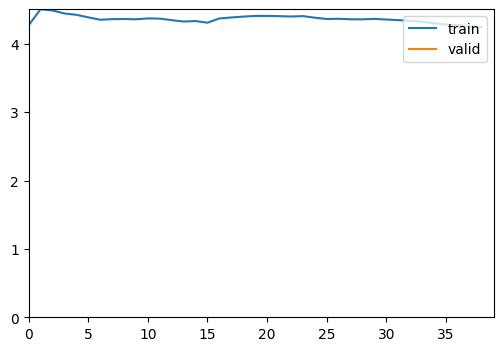

epoch,train_loss,valid_loss,time
0,3.763656,3.431993,00:09
1,3.620042,3.395424,00:09
2,3.520349,3.369038,00:09
3,3.471203,3.242285,00:09
4,3.399164,3.448793,00:09
5,3.294286,3.031656,00:09
6,3.221377,2.919353,00:09
7,3.065816,3.007944,00:09
8,2.974945,3.211515,00:09
9,3.003502,2.971006,00:09


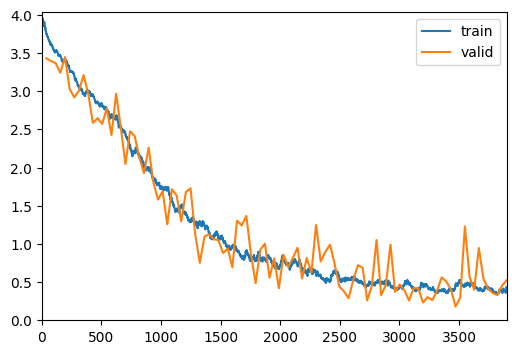

In [11]:
learn.fine_tune(100, base_lr=1e-3, cbs=[ShowGraphCallback()])

In [12]:
learn.model.encoder

MobileNetV3(
  (conv_stem): Conv2dSame(3, 16, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): Hardswish()
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
        (bn1): BatchNormAct2d(
          16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (se): Identity()
        (conv_pw): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNormAct2d(
          16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): Identity()
        )
        (drop_path): Identity()
      )
    )
    (1): Sequential(
      (0): Invert

In [13]:
import torch
torch.save(learn.model.encoder.state_dict(), "simclr_encoder_mobilenetv3_large.pth")

In [14]:
import torch.nn as nn

pretrained_encoder = torch.load("simclr_encoder_mobilenetv3_large.pth")
encoder = create_encoder("tf_mobilenetv3_large_100.in1k", pretrained=False, n_in=3)
encoder.load_state_dict(pretrained_encoder)
nf = encoder(torch.randn(2,3,224,224)).size(-1)
classifier = create_cls_module(nf, dls.c)
model = nn.Sequential(encoder, classifier)
learn = Learner(dls, model, metrics=[accuracy,top_k_accuracy], loss_func=LabelSmoothingCrossEntropy())



/tmp/ipykernel_274724/1386070518.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_encoder = torch.load("simclr_encoder_mobilenetv3_large.pth")


SuggestedLRs(valley=7.585775892948732e-05)

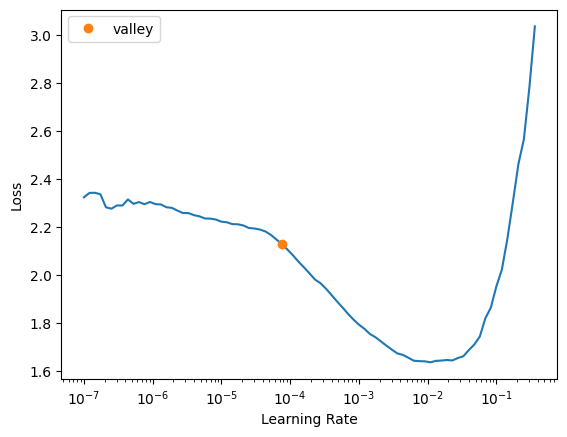

In [15]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,top_k_accuracy,time
0,1.671539,1.046219,0.714286,0.985714,00:04


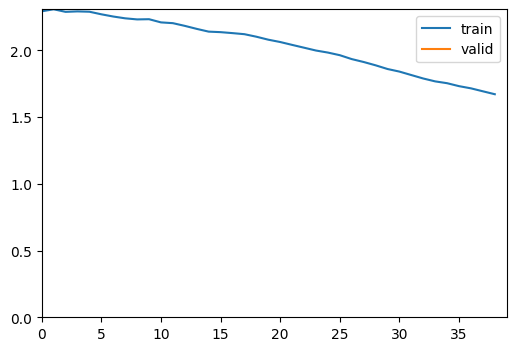

epoch,train_loss,valid_loss,accuracy,top_k_accuracy,time
0,1.131240,1.018006,0.717857,0.989286,00:04
1,1.101348,0.994689,0.742857,0.989286,00:04
2,1.083358,0.979146,0.760714,0.992857,00:04
3,1.052534,0.960430,0.775000,1.000000,00:04
4,1.022971,0.943261,0.767857,1.000000,00:04
5,1.002863,0.933608,0.775000,1.000000,00:04
6,0.981982,0.920300,0.767857,1.000000,00:04
7,0.958993,0.910663,0.778571,1.000000,00:04
8,0.937054,0.902166,0.782143,1.000000,00:04
9,0.910346,0.876225,0.796429,1.000000,00:04


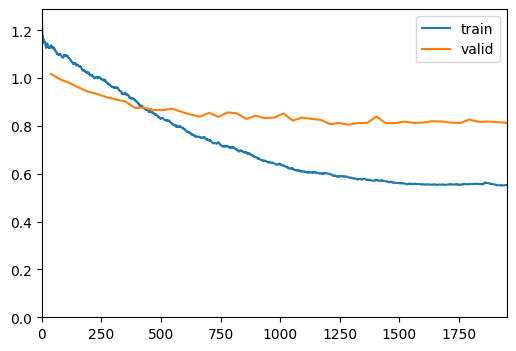

In [16]:
learn.fine_tune(50, base_lr=1e-4, cbs=[ShowGraphCallback()])

In [17]:
learn.model[0]

MobileNetV3(
  (conv_stem): Conv2dSame(3, 16, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): Hardswish()
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
        (bn1): BatchNormAct2d(
          16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (se): Identity()
        (conv_pw): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNormAct2d(
          16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): Identity()
        )
        (drop_path): Identity()
      )
    )
    (1): Sequential(
      (0): Invert

In [18]:
torch.save(learn.model[0].state_dict(), "simclr_finetuned_mobilenetv3_large_10epochs.pth")

In [19]:
import timm
import torch

model = timm.create_model("tf_mobilenetv3_large_100.in1k", num_classes=0, in_chans=3, global_pool=PoolingType.CatAvgMax)
checkpoint = torch.load("simclr_finetuned_mobilenetv3_large_10epochs.pth")
model.load_state_dict(checkpoint, strict=False)
model = model.to("cuda")



/tmp/ipykernel_274724/3577500761.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("simclr_finetuned_mobilenetv3_large_10epochs.pth")


In [20]:
import timm
from PIL import Image

data_config = timm.data.resolve_model_data_config(model)
transforms = timm.data.create_transform(**data_config, is_training=False)



In [21]:
def get_batch_embeddings(image_dir, batch_size=32):
    """
    Get embeddings for all images in a directory using batch processing
    
    Args:
        image_dir (str): Path to directory containing images
        batch_size (int): Number of images to process at once
        
    Returns:
        torch.Tensor: Embeddings for all images (n_images x embedding_dim)
    """
    from pathlib import Path
    import torch
    from PIL import Image
    from tqdm.auto import tqdm
    
    image_files = []
    for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
        image_files.extend(Path(image_dir).rglob(f'*{ext}'))
    
    all_embeddings = []
    
    for i in tqdm(range(0, len(image_files), batch_size), desc="Processing images"):
        batch_files = image_files[i:i + batch_size]
        batch_images = []
        
        # Load and transform each image in the batch
        for img_path in batch_files:
            img = Image.open(img_path)
            img_tensor = transforms(img)
            batch_images.append(img_tensor)
            
        # Stack batch and get embeddings
        batch_tensor = torch.stack(batch_images)
        
        with torch.inference_mode():
            batch_embeddings = model(batch_tensor.to("cuda"))
            
        all_embeddings.append(batch_embeddings)
    
    # Concatenate all batches
    return torch.cat(all_embeddings, dim=0)


embeddings = get_batch_embeddings("../../data/RSSCN7/data", batch_size=1000)
embeddings.shape

Processing images:   0%|          | 0/3 [00:00<?, ?it/s]

torch.Size([2800, 1280])

In [22]:
import numpy as np

np.save("simclr_finetuned_mobilenetv3_large_10epochs_embeddings.npy", embeddings.cpu().numpy())

In [23]:
embeddings = np.load("simclr_finetuned_mobilenetv3_large_10epochs_embeddings.npy")
embeddings.shape

(2800, 1280)

INFO:faiss.loader:Loading faiss with AVX512 support.
INFO:faiss.loader:Successfully loaded faiss with AVX512 support.


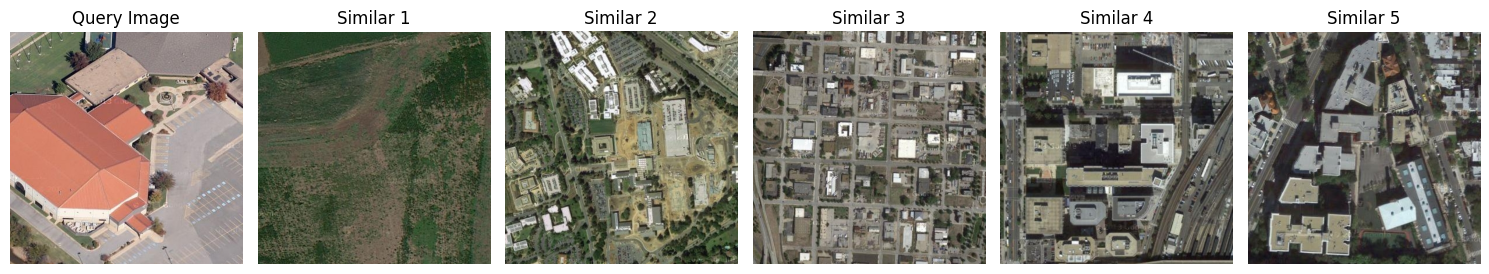

In [24]:
import faiss
from pathlib import Path
import matplotlib.pyplot as plt
set_seed(42)

def plot_similar_images(query_idx, similar_indices, image_dir, n_images=5):
    """
    Plot query image and its nearest neighbors
    
    Args:
        query_idx (int): Index of the query image
        similar_indices (np.ndarray): Indices of similar images
        image_dir (str): Directory containing the images
        n_images (int): Number of similar images to display
    """
    # Get list of image files in the same order as embeddings
    image_files = []
    for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
        image_files.extend(sorted(Path(image_dir).rglob(f'*{ext}')))
    
    # Create a figure with n_images + 1 subplots (query + neighbors)
    fig, axes = plt.subplots(1, n_images + 1, figsize=(15, 3))
    
    # Plot query image
    query_img = Image.open(image_files[query_idx])
    axes[0].imshow(query_img)
    axes[0].set_title('Query Image')
    axes[0].axis('off')
    
    # Plot similar images
    for idx, ax in enumerate(axes[1:]):
        similar_img = Image.open(image_files[similar_indices[idx]])
        ax.imshow(similar_img)
        ax.set_title(f'Similar {idx+1}')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Normalize the embeddings
embeddings_normalized = embeddings.astype('float32')
faiss.normalize_L2(embeddings_normalized)  # in-place normalization

# Create FAISS index using inner product (IP) distance
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)  # IP = Inner Product
index.add(embeddings_normalized)

# Example: Find similar images for a random query
k = 6  # number of nearest neighbors to retrieve
query_idx = np.random.randint(0, len(embeddings))

# Normalize query vector
query_vector = embeddings[query_idx:query_idx+1].astype('float32')
faiss.normalize_L2(query_vector)

# Search
similarities, indices = index.search(query_vector, k)

# Visualize results
plot_similar_images(query_idx, indices[0][1:], "../../data/RSSCN7/data") 

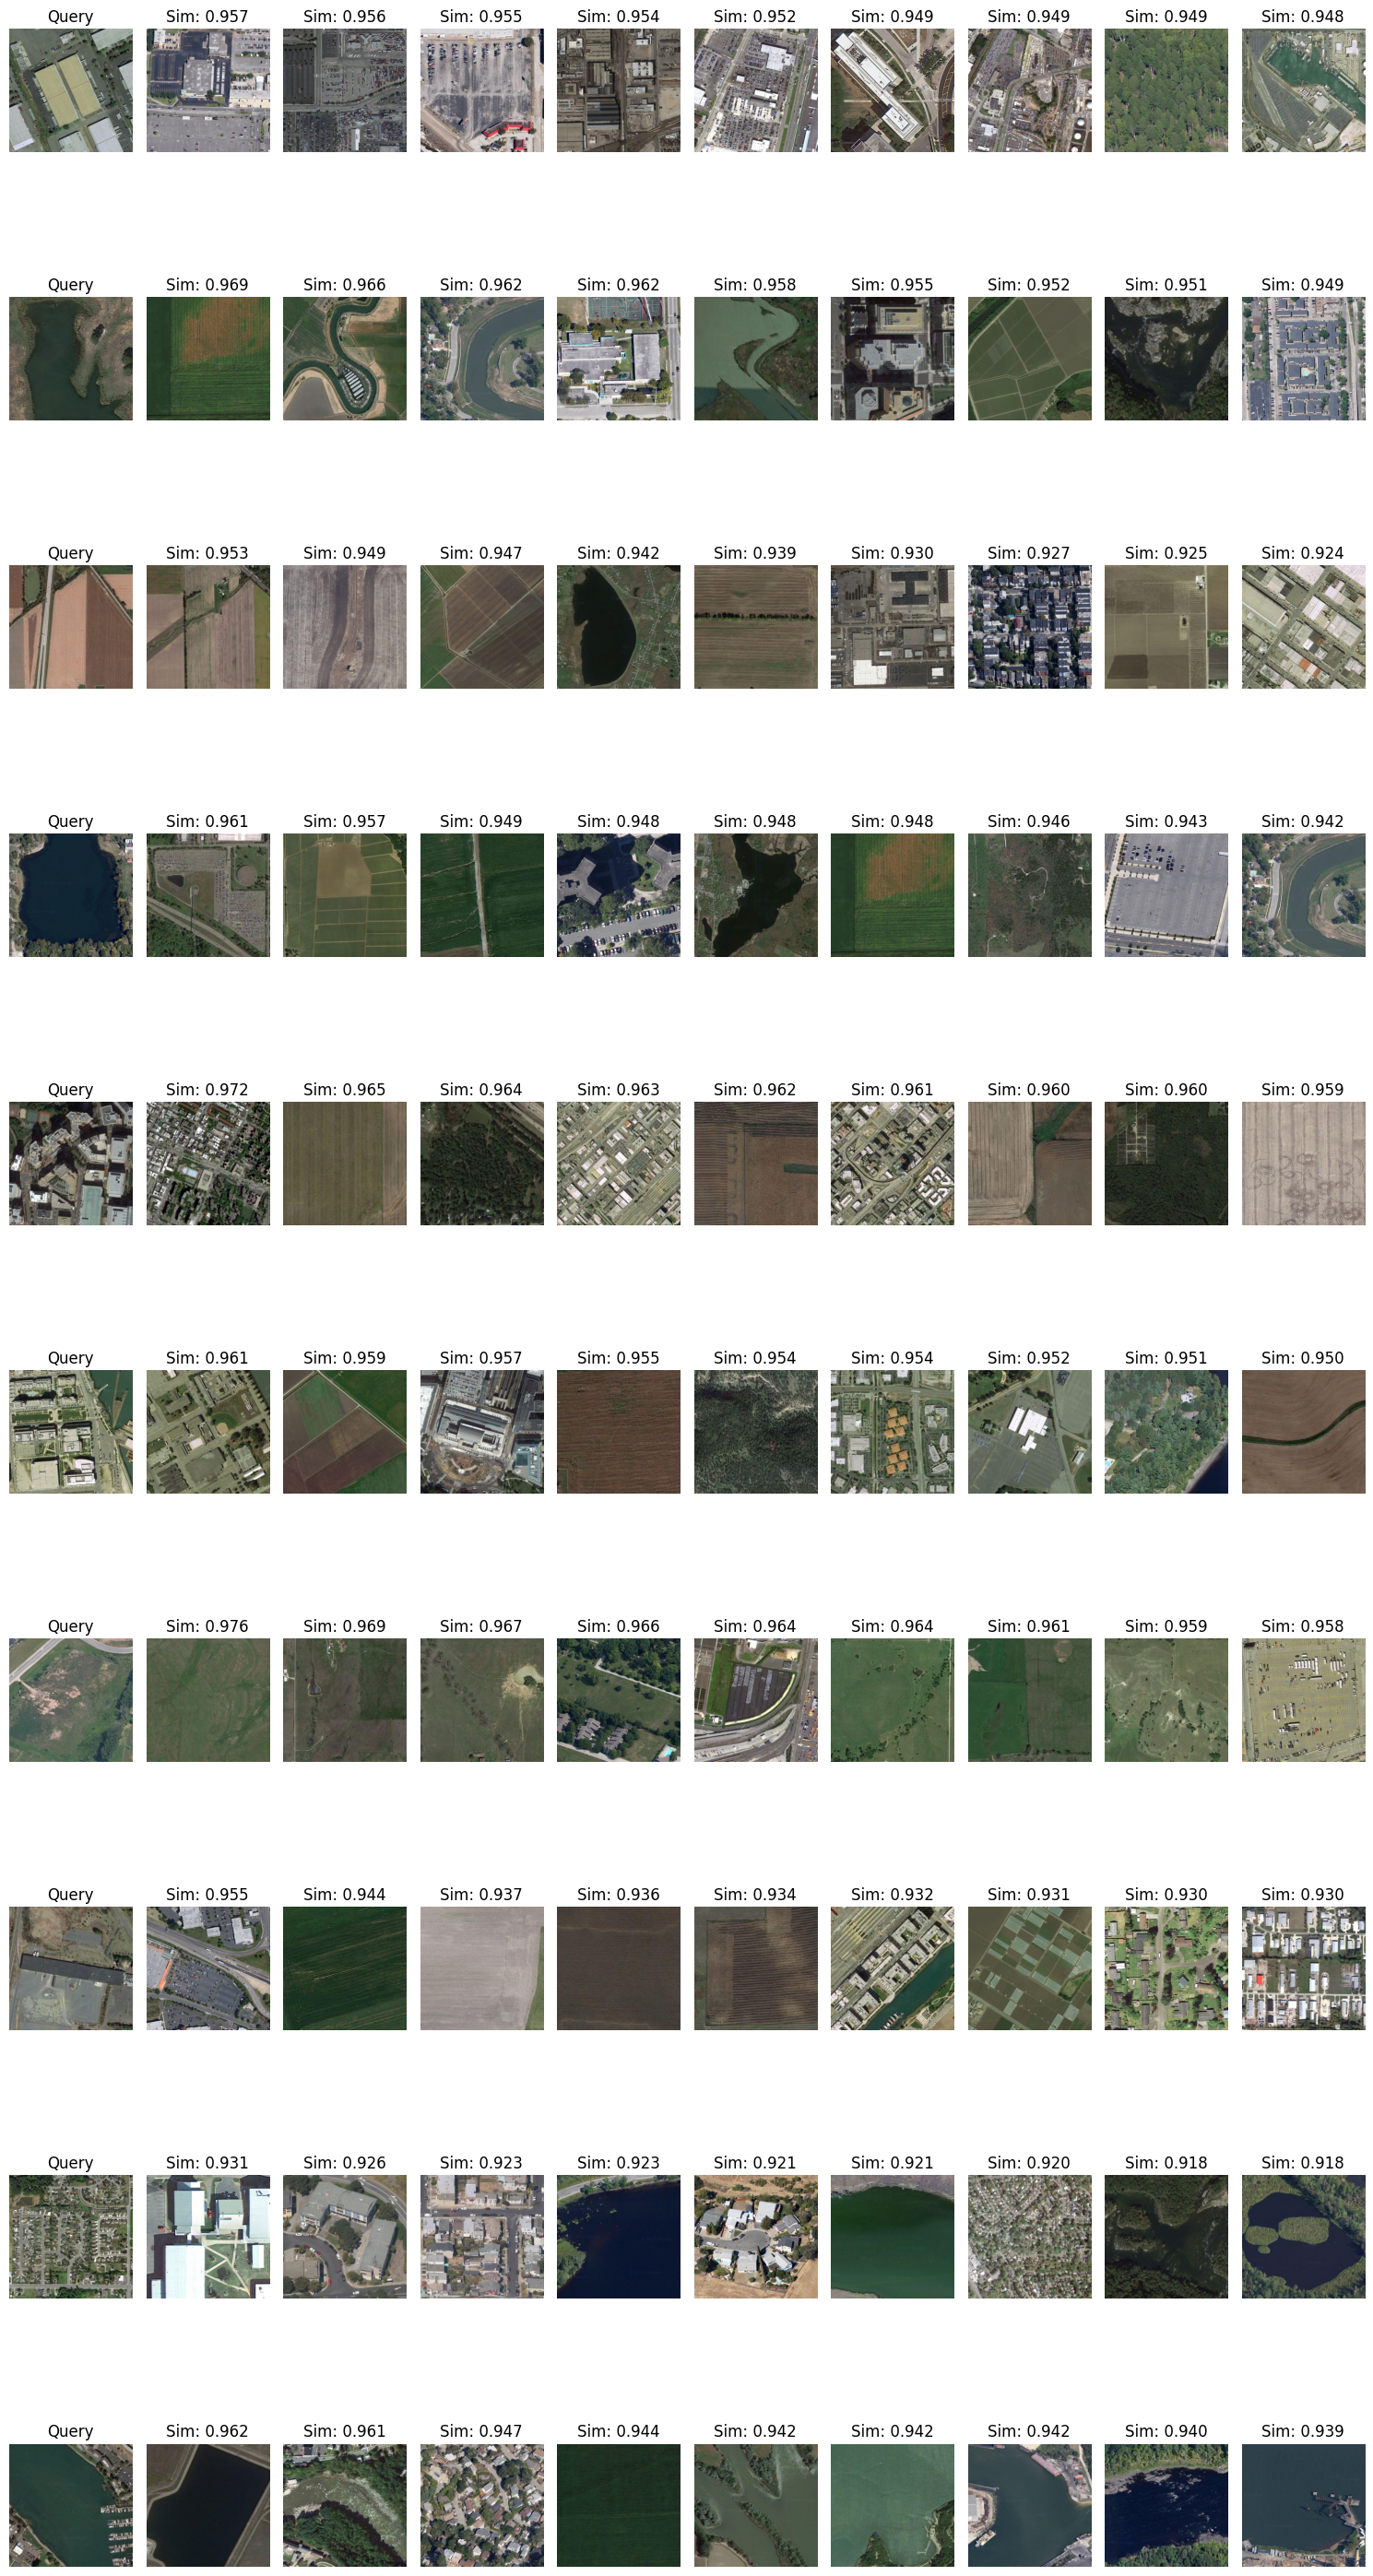

In [25]:


def plot_multiple_queries(query_indices, similar_indices, similarities, image_dir, n_neighbors=5, figsize=(15, 3)):
    """
    Plot multiple rows of query images and their nearest neighbors
    
    Args:
        query_indices (list): List of query image indices
        similar_indices (np.ndarray): Array of similar image indices for each query
        similarities (np.ndarray): Array of similarity scores
        image_dir (str): Directory containing the images
        n_neighbors (int): Number of similar images to display per query
        figsize (tuple): Base figure size for a single row (will be scaled by number of rows)
    """
    n_queries = len(query_indices)
    
    # Get list of image files in the same order as embeddings
    image_files = []
    for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
        image_files.extend(sorted(Path(image_dir).rglob(f'*{ext}')))
    
    # Create a figure with n_queries rows
    fig, axes = plt.subplots(n_queries, n_neighbors + 1, 
                            figsize=(figsize[0], figsize[1] * n_queries))
    if n_queries == 1:
        axes = axes[None, :]  # Add dimension for consistent indexing
    
    for row, (query_idx, sim_indices, sim_scores) in enumerate(zip(query_indices, similar_indices, similarities)):
        # Plot query image
        query_img = Image.open(image_files[query_idx])
        axes[row, 0].imshow(query_img)
        axes[row, 0].set_title('Query')
        axes[row, 0].axis('off')
        
        # Plot similar images
        for col, (idx, score) in enumerate(zip(sim_indices[1:], sim_scores[1:]), 1):
            similar_img = Image.open(image_files[idx])
            axes[row, col].imshow(similar_img)
            axes[row, col].set_title(f'Sim: {score:.3f}')
            axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

# Example usage:
n_queries = 10  # Number of random queries to show
k = 10  # number of nearest neighbors to retrieve

# Generate random query indices
query_indices = np.random.choice(len(embeddings), n_queries, replace=False)
# query_indices = [0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000]

# Get similar images for all queries
all_similarities = []
all_indices = []

for idx in query_indices:
    query_vector = embeddings[idx:idx+1].astype('float32')
    faiss.normalize_L2(query_vector)
    similarities, indices = index.search(query_vector, k)
    all_similarities.append(similarities[0])
    all_indices.append(indices[0])

# Visualize results
plot_multiple_queries(
    query_indices, 
    np.array(all_indices), 
    np.array(all_similarities), 
    "../../data/RSSCN7/data",
    n_neighbors=9
)